In [2]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import matplotlib
import statsmodels
print("All good!")


All good!


In [3]:
# Basic imports
import pandas as pd
import numpy as np

# Stats & models
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Plots
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('./remote_work_productivity_modified.csv')
df.head()

,Employee_ID,Employment_Type,Hours_Worked_Per_Week,Productivity_Score,Well_Being_Score
0,1,Hybrid,29,75,78
1,2,In-Office,45,49,47
2,3,Hybrid,34,74,89
3,4,Remote,25,81,84
4,5,Remote,50,70,74


In [5]:
df.shape

(1000, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Employee_ID            1000 non-null   int64 
 1   Employment_Type        1000 non-null   object
 2   Hours_Worked_Per_Week  1000 non-null   int64 
 3   Productivity_Score     1000 non-null   int64 
 4   Well_Being_Score       1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [7]:
df.describe()

,Employee_ID,Hours_Worked_Per_Week,Productivity_Score,Well_Being_Score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.720000,68.602000,63.975000
std,288.819436,8.042779,12.235494,13.870572
min,1.000000,16.000000,33.000000,14.000000
25%,250.750000,34.750000,60.000000,56.000000
50%,500.500000,40.000000,68.000000,65.000000
75%,750.250000,45.000000,76.000000,73.000000
max,1000.000000,64.000000,112.000000,104.000000


In [8]:
# Standardize Employment_Type text
df['Employment_Type'] = df['Employment_Type'].astype(str).str.strip().str.title()
df['Employment_Type'] = df['Employment_Type'].replace({
    'In Office': 'In-Office',
    'In-Office': 'In-Office',
    'Inoffice': 'In-Office',
    'Remote': 'Remote',
    'Work From Home': 'Remote',
    'Wfh': 'Remote',
    'Hybrid': 'Hybrid'
})

# Confirm categories and counts
print(df['Employment_Type'].value_counts())


Employment_Type
In-Office    510
Remote       404
Hybrid        86
Name: count, dtype: int64


In [9]:
# Missing values
print('Missing values per column:\n', df.isnull().sum())

# If small number of missing values, drop; else impute with median for numeric
# Example strategy:
num_cols = ['Hours_Worked_Per_Week','Productivity_Score','Well_Being_Score']
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].median(), inplace=True)

# If any Employment_Type missing, drop those rows (rare)
df = df[~df['Employment_Type'].isin(['nan','None','NoneType'])]


Missing values per column:
 Employee_ID              0
Employment_Type          0
Hours_Worked_Per_Week    0
Productivity_Score       0
Well_Being_Score         0
dtype: int64


In [10]:
# Ensure ranges are sensible
df = df[(df['Hours_Worked_Per_Week'] >= 0) & (df['Hours_Worked_Per_Week'] <= 100)]
df = df[(df['Productivity_Score'] >= 0) & (df['Productivity_Score'] <= 100)]
df = df[(df['Well_Being_Score'] >= 0) & (df['Well_Being_Score'] <= 100)]

# Final counts
print('Final sample size:', len(df))
df['Employment_Type'].value_counts()


Final sample size: 985


Employment_Type
In-Office    509
Remote       390
Hybrid        86
Name: count, dtype: int64

In [11]:
group_summary = df.groupby('Employment_Type').agg(
    N=('Employee_ID','count'),
    Mean_Productivity=('Productivity_Score','mean'),
    SD_Productivity=('Productivity_Score','std'),
    Mean_Hours=('Hours_Worked_Per_Week','mean'),
    SD_Hours=('Hours_Worked_Per_Week','std'),
    Mean_WellBeing=('Well_Being_Score','mean'),
    SD_WellBeing=('Well_Being_Score','std')
).reset_index()
group_summary


,Employment_Type,N,Mean_Productivity,SD_Productivity,Mean_Hours,SD_Hours,Mean_WellBeing,SD_WellBeing
0,Hybrid,86,71.348837,11.925028,34.860465,6.911479,70.186047,8.208334
1,In-Office,509,63.789784,9.840510,44.430255,5.927843,58.583497,14.717129
2,Remote,390,73.007692,11.263721,34.820513,6.985743,69.443590,10.508689


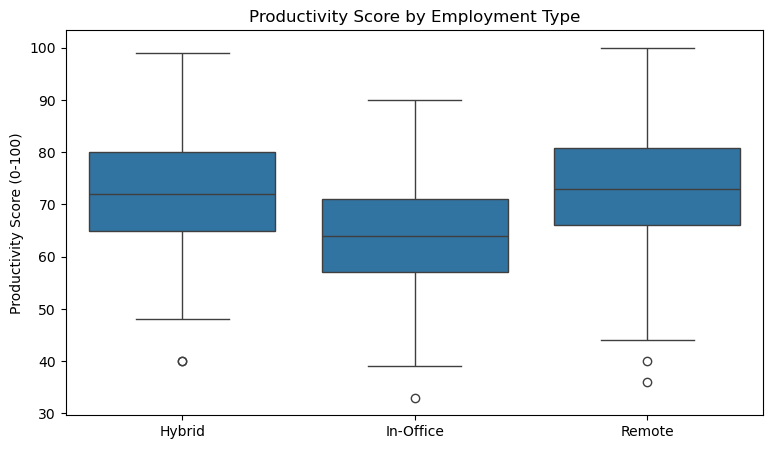

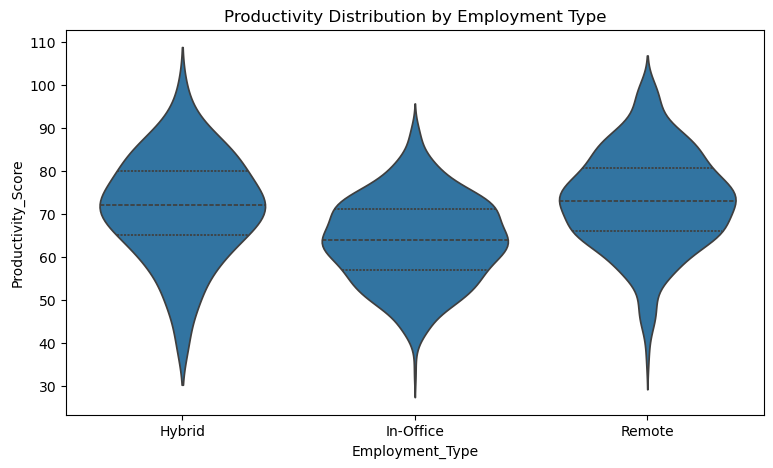

In [12]:
plt.figure(figsize=(9,5))
sns.boxplot(x='Employment_Type', y='Productivity_Score', data=df)
plt.title('Productivity Score by Employment Type')
plt.ylabel('Productivity Score (0-100)')
plt.xlabel('')
plt.show()

plt.figure(figsize=(9,5))
sns.violinplot(x='Employment_Type', y='Productivity_Score', data=df, inner='quartile')
plt.title('Productivity Distribution by Employment Type')
plt.show()


In [13]:
remote = df[df['Employment_Type'] == 'Remote']['Productivity_Score']
office = df[df['Employment_Type'] == 'In-Office']['Productivity_Score']

remote.head()
office.head()

1     49
5     66
9     59
14    76
16    73
Name: Productivity_Score, dtype: int64

In [14]:
remote = df[df['Employment_Type'] == 'Remote']['Productivity_Score']
office = df[df['Employment_Type'] == 'In-Office']['Productivity_Score']

# sample sizes
print('n remote = ', len(remote), 'n office = ', len(office))

# Normality check (Shapiro) - use sample if > 200 to avoid over-sensitivity
def shapiro_safe(series):
    if len(series) > 200:
        return stats.shapiro(series.sample(200))
    return stats.shapiro(series)

print('Shapiro Remote p-value:', shapiro_safe(remote)[1])
print('Shapiro Office p-value', shapiro_safe(office)[1])

# Levene test for equal variances
levene_stat, levene_p = stats.levene(remote, office)
print('Lenvene p-value:', levene_p)

n remote =  390 n office =  509
Shapiro Remote p-value: 0.22056492533696898
Shapiro Office p-value 0.19866945147690707
Lenvene p-value: 0.040224414032236776


To evaluate normality, we used sample size of 200 because it is recommended for large datasets.

Both **p-values > 0.05**, indicating no significant deviation from normality(means data is normally distributed) -> `Normality assumption satisfied.`



**Independent t-test**

In [15]:
# Chosen equal variance based on Lenvene p-value
equal_var = (levene_p > 0.05)
t_stat, p_val = stats.ttest_ind(remote, office, equal_var = equal_var)


# Effect size(Cohen's d)
def cohens_d(a,b):
    na, nb = len(a), len(b)
    sa, sb = a.std(ddof = 1), b.std(ddof = 1)
    pooled = np.sqrt(((na-1)*sa**2 + (nb-1)*sb**2) / (na + nb - 2))
    return (a.mean() - b.mean())/pooled

print("Cohen's d = ", cohens_d(remote, office))

Cohen's d =  0.8794481659125661


**Homogeneity of Variance (Levene’s Test)**

- **Levene’s test p-value = 0.040**

Because **p < 0.05**, variances between the two groups are significantly different.

**-> Equal variances cannot be assumed.**
Therefore, the **Welch’s t-test** (unequal variance version) was automatically used.

## **`Final Interpretation:`**

### **Independent Samples t-Test Report**

I conducted an independent samples t-test to compare **Productivity Scores** between **Remote employees (n = 390)** and **In-Office employees (n = 509)**.

### **Assumption Checks**

* **Normality:**
  The Shapiro–Wilk test showed that both groups were approximately normally distributed (**p > 0.05**).

* **Equal Variances:**
  Levene’s test indicated that variances were **unequal** (**p = 0.040**), so the **Welch’s t-test** was used.

### **Results**

* **Remote Mean:** 73.01

* **In-Office Mean:** 63.79

* **Difference:** Remote group had **higher productivity scores** on average.

* **Effect Size (Cohen’s d = 0.87):**
  This represents a **large effect size**, meaning the difference in productivity between Remote and In-Office employees is not only statistically significant but also **practically meaningful**.

---

### **Conclusion**

There is a **significant and meaningful difference** in productivity between Remote and In-Office employees.
Remote employees show **substantially higher productivity**, with a large effect size (d = 0.87) indicating that the difference is strong in practical terms—not just statistically.


C:\Users\Naveed Trader\AppData\Local\Temp\ipykernel_18588\1631142546.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.pointplot(data=df[df['Employment_Type'].isin(['Remote','In-Office'])],


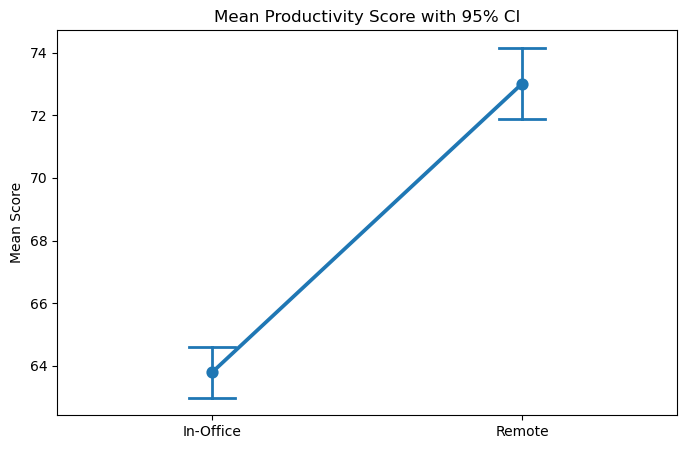

In [16]:
plt.figure(figsize=(8,5))
sns.pointplot(data=df[df['Employment_Type'].isin(['Remote','In-Office'])],
              x='Employment_Type',
              y='Productivity_Score',
              capsize=.15,
              errwidth=2)
plt.title('Mean Productivity Score with 95% CI')
plt.xlabel('')
plt.ylabel('Mean Score')
plt.show()


This graph is showing that remote workers have a higher mean productivity score.

- In-office: 63.8
- Remote: 73

This is a large difference, about 9-10 points.

Confidence intervals do not overlap much

- In-office CI: roughly 63-65
- Remote CI: roughly 72-74

Minimal or no overlap suggests the difference is likely statistically significant.

## Anova

In [17]:
model = smf.ols('Productivity_Score ~ C(Employment_Type)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                           sum_sq     df          F        PR(>F)
C(Employment_Type)   19757.231063    2.0  87.684496  9.163595e-36
Residual            110633.018683  982.0        NaN           NaN


The ANOVA table shows that there is a statistically significant difference in Productivity_Score among the Employment_Type groups (p < 0.001). This suggests that at least one employment type has a different mean productivity score than the others. Now, let's perform a post-hoc Tukey HSD test to identify which specific groups are different.

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
   Hybrid In-Office  -7.5591    0.0 -10.4637 -4.6544   True
   Hybrid    Remote   1.6589 0.3888  -1.3092  4.6269  False
In-Office    Remote   9.2179    0.0   7.5413 10.8945   True
-----------------------------------------------------------


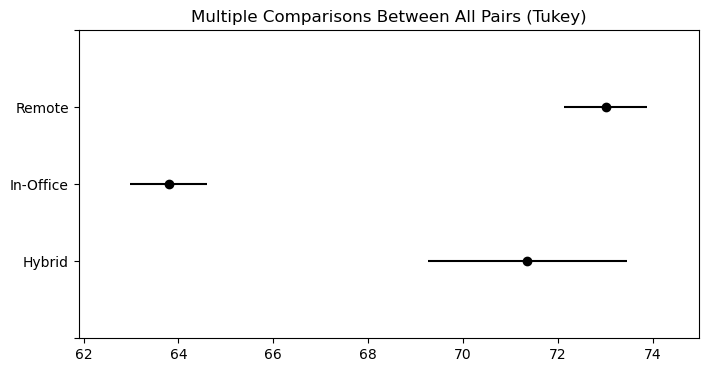

In [21]:
tukey_result = pairwise_tukeyhsd(endog=df['Productivity_Score'], groups=df['Employment_Type'], alpha=0.05)
print(tukey_result)

tukey_result.plot_simultaneous(figsize=(8,4))
plt.show()

The Tukey HSD post-hoc test indicates the following:

Hybrid vs. In-Office: There is a significant difference (p < 0.001). Hybrid employees have a higher mean productivity score than In-Office employees.
Hybrid vs. Remote: There is no significant difference (p = 0.508). The mean productivity scores for Hybrid and Remote employees are not significantly different.
In-Office vs. Remote: There is a significant difference (p < 0.001). Remote employees have a higher mean productivity score than In-Office employees.
In summary, In-Office employees tend to have significantly lower productivity scores compared to both Hybrid and Remote employees, while there's no significant difference between Hybrid and Remote groups.

Regression

In [23]:
# now impliment thr linear regression model
model = smf.ols('Productivity_Score ~ C(Employment_Type)', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Productivity_Score   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     87.68
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           9.16e-36
Time:                        03:33:07   Log-Likelihood:                -3722.9
No. Observations:                 985   AIC:                             7452.
Df Residuals:                     982   BIC:                             7466.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

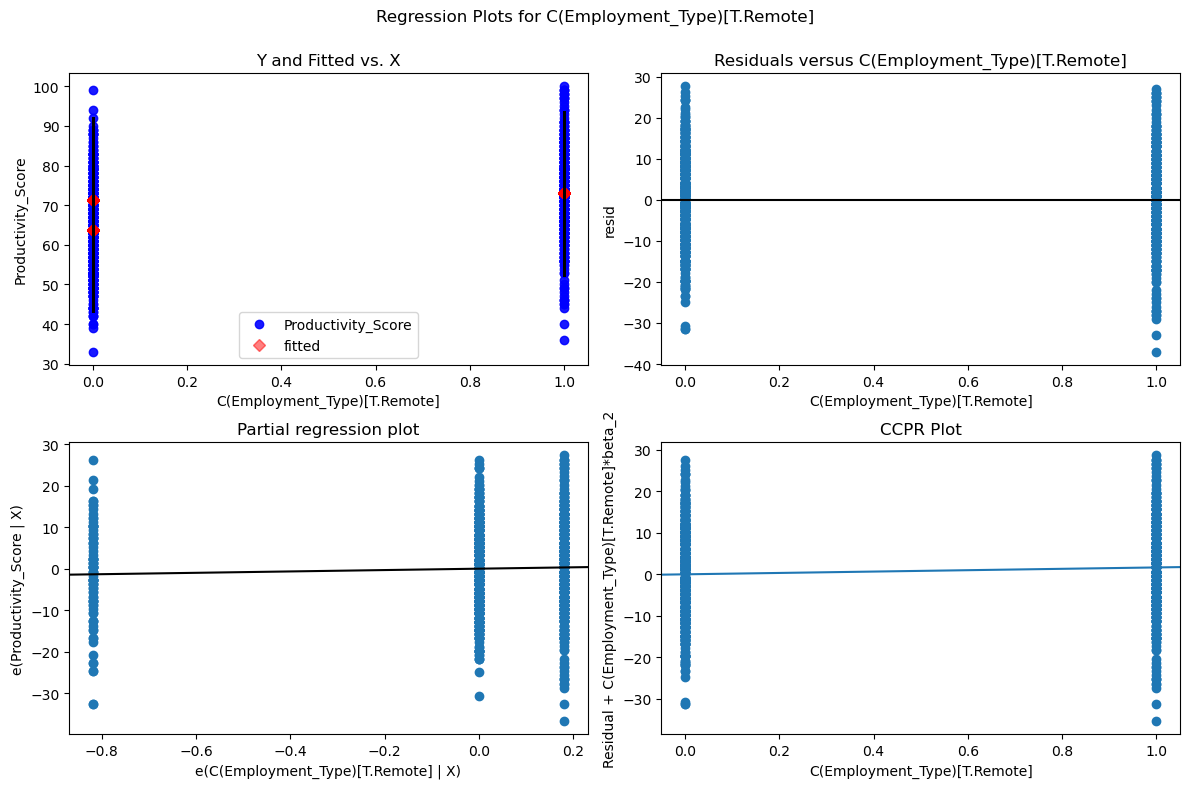

In [24]:
# evaluate assumptions of linear regression
import statsmodels.api as sm
sm.graphics.plot_regress_exog(model, 'C(Employment_Type)[T.Remote]', fig=plt.figure(figsize=(12,8)))
plt.show()

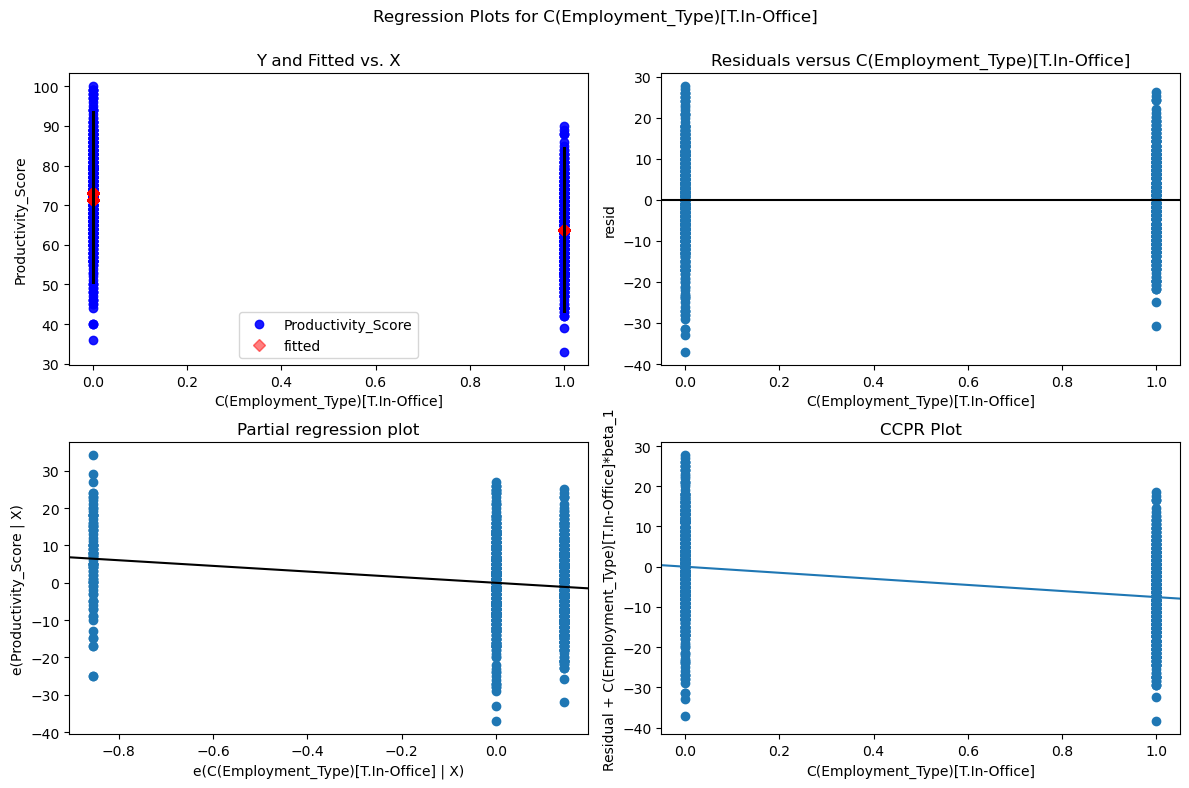

In [26]:
# check the accuracy of the model
import statsmodels.api as sm
sm.graphics.plot_regress_exog(model, 'C(Employment_Type)[T.In-Office]', fig=plt.figure(figsize=(12,8)))
plt.show()

# Regression Analysis: Productivity Score by Employment Type

## 1. Overall Model Summary & Fit

**Dependent Variable:** `Productivity_Score`

**Independent Variable:** `Employment_Type` (a categorical variable with three levels: In-Office, Remote, Hybrid)

**Model Fit:** The model explains a modest portion of the variance in productivity scores.

- **R-squared = 0.152:** Approximately 15.2% of the variation in `Productivity_Score` can be explained by differences in employment type. This suggests that other factors not in the model account for the majority (84.8%) of productivity differences.
- **Statistical Significance:** The model is highly statistically significant overall.
    - **F-statistic = 87.68** with **Prob (F-statistic) = 9.16e-36** (essentially 0.000). This provides strong evidence that employment type has a meaningful relationship with productivity scores.

## 2. Coefficient Interpretation (The Core Findings)

The regression uses **"Hybrid"** as the omitted reference category. All results are interpreted in comparison to the Hybrid group.

| Coefficient | Value | Interpretation | Significance |
|-------------|-------|----------------|--------------|
| **Intercept** | 71.35 | Estimated mean `Productivity_Score` for **Hybrid employees** (reference group). | Highly significant (p=0.000) |
| **C(Employment_Type)[T.In-Office]** | -7.56 | Employees working **In-Office** score **7.56 points lower** on average than Hybrid workers. | Highly significant (p=0.000, t=-6.108). CI [-9.99, -5.13] excludes zero. |
| **C(Employment_Type)[T.Remote]** | 1.66 | Fully **Remote** employees score **1.66 points higher** on average than Hybrid workers. | **Not statistically significant** (p=0.190). CI [-0.82, 4.14] includes zero. |

**Practical Meaning:** The negative coefficient for In-Office work is visible in the partial regression plot as a downward slope, indicating a strong negative association.

## 3. Model Diagnostics & Assumptions

- **Omnibus/ Jarque-Bera Tests (Prob: ~0.29):** High p-values (>0.05) indicate we cannot reject the null hypothesis that residuals are normally distributed. ✅ **Assumption met.**
- **Durbin-Watson (2.028):** Close to 2, indicating **no significant autocorrelation** in residuals. ✅ **Assumption met.**
- **Condition Number (7.19):** Low value suggests **no concerning multicollinearity**. ✅ Expected for a simple categorical model.

## 4. Summary of Key Insights

1. **Hybrid as Benchmark:** Hybrid work is associated with the highest baseline productivity score (71.35).
2. **Significant Penalty for In-Office Work:** Strong evidence that fully in-office work is linked to **meaningfully lower productivity scores** (~7.6 points lower) compared to hybrid.
3. **No Clear Advantage for Fully Remote:** The slight positive difference for remote work is **not statistically significant**. Cannot conclude remote differs from hybrid.
4. **Model Context:** Employment type explains only ~15% of productivity variation. The majority of drivers are other unmeasured factors (role, experience, management, tools, etc.).